In [ ]:
import os, sys, subprocess, importlib.util, functools, dataclasses, time, math

def _sh(cmd):
    subprocess.run(cmd, shell=True, check=False,
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

print("Installing dependencies ...")
_sh(f'{sys.executable} -m pip install -q "etils[array-types,epy,etree,enp]" '
    f'chex flax optax scikit-image')

REPO_DIR = "/content/jax3d" if os.path.isdir("/content") else os.path.abspath("./jax3d")
if not os.path.isdir(REPO_DIR):
    print("Cloning google-research/jax3d ...")
    _sh(f"git clone -q --depth 1 https://github.com/google-research/jax3d.git {REPO_DIR}")

def _load_module_by_path(name, path):
    """Load a single .py file without triggering the parent package __init__.

    `from jax3d.math import volume_rendering` also works if you run
    `pip install .` inside the clone, but that pulls in gin/tfds/etc.
    """
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

_VR_PATH = os.path.join(REPO_DIR, "jax3d", "jax3d", "math", "volume_rendering.py")
if not os.path.exists(_VR_PATH):
    _VR_PATH = os.path.join(REPO_DIR, "jax3d", "math", "volume_rendering.py")
try:
    j3vr = _load_module_by_path("j3d_volume_rendering", _VR_PATH)
except Exception as e:
    raise SystemExit(
        f"Could not load {_VR_PATH}: {e}\n"
        "Try: pip install -U 'etils[array-types,epy,etree,enp]==1.9.4' and re-run."
    )

import numpy as np
import jax
import jax.numpy as jnp
import flax.linen as nn
import optax
from flax.training import train_state
import matplotlib.pyplot as plt
from PIL import Image

print("jax", jax.__version__, "| device:", jax.devices()[0].device_kind,
      f"({jax.devices()[0].platform})")
print("jax3d volume_rendering API:",
      [n for n in ("sample_along_rays", "volume_rendering",
                   "sample_piecewise_constant_pdf", "sample_1d")
       if hasattr(j3vr, n)])

@dataclasses.dataclass
class Config:
    H: int = 64;            W: int = 64
    n_train_views: int = 24; n_test_views: int = 3
    cam_radius: float = 3.2; fov_deg: float = 40.0
    near: float = 1.9;       far: float = 4.7
    gt_samples: int = 256
    n_coarse: int = 64;      n_fine: int = 64
    deg_pos: int = 10;       deg_dir: int = 4
    width: int = 128;        depth: int = 6;   skip: int = 3
    batch_rays: int = 2048;  steps: int = 2500
    lr_init: float = 5e-4;   lr_final: float = 5e-6
    chunk: int = 4096
    grid_res: int = 96

cfg = Config()
if jax.devices()[0].platform == "cpu":
    print("\n!! No GPU detected -- switching to a small CPU-friendly config.")
    print("   (Runtime > Change runtime type > T4 GPU for the full version.)\n")
    cfg = dataclasses.replace(cfg, H=40, W=40, n_train_views=14, steps=400,
                              gt_samples=128, n_coarse=32, n_fine=32,
                              width=64, depth=4, skip=2, batch_rays=1024,
                              chunk=1600, grid_res=64)

def _normalize(v, axis=-1):
    return v / (np.linalg.norm(v, axis=axis, keepdims=True) + 1e-9)

def look_at(eye, target=(0., 0., 0.), up=(0., 0., 1.)):
    """OpenGL/NeRF convention camera-to-world: +x right, +y up, camera looks at -z."""
    eye, target, up = map(lambda a: np.asarray(a, np.float32), (eye, target, up))
    fwd   = _normalize(target - eye)
    right = _normalize(np.cross(fwd, up))
    trueup = np.cross(right, fwd)
    c2w = np.eye(4, dtype=np.float32)
    c2w[:3, :3] = np.stack([right, trueup, -fwd], axis=1)
    c2w[:3, 3] = eye
    return c2w

def orbit_poses(n, radius, elev_lo=18., elev_hi=58., phase=0.0):
    """Golden-angle azimuths + monotone elevations => well-spread views on a dome."""
    i = np.arange(n, dtype=np.float64) + 0.5
    az = 2 * np.pi * ((i * 0.6180339887) + phase)
    elev = np.arcsin(np.linspace(np.sin(np.deg2rad(elev_lo)),
                                 np.sin(np.deg2rad(elev_hi)), n))
    eyes = np.stack([radius * np.cos(elev) * np.cos(az),
                     radius * np.cos(elev) * np.sin(az),
                     radius * np.sin(elev)], axis=-1).astype(np.float32)
    return np.stack([look_at(e) for e in eyes], axis=0)

def rays_from_pose(c2w, H, W, focal):
    """Returns (origins, dirs) of shape [H, W, 3]; dirs are unit-length, so the
    depths returned by jax3d's sampler are true world-space distances."""
    i, j = np.meshgrid(np.arange(W, dtype=np.float32),
                       np.arange(H, dtype=np.float32), indexing="xy")
    cam_dirs = np.stack([(i - W * .5 + .5) / focal,
                         -(j - H * .5 + .5) / focal,
                         -np.ones_like(i)], axis=-1)
    dirs = _normalize(cam_dirs @ c2w[:3, :3].T)
    origins = np.broadcast_to(c2w[:3, 3], dirs.shape)
    return origins.astype(np.float32).copy(), dirs.astype(np.float32)

FOCAL = 0.5 * cfg.W / math.tan(0.5 * math.radians(cfg.fov_deg))

In [ ]:
LIGHT = jnp.asarray(_normalize(np.array([0.55, 0.75, 0.85], np.float32)))

_SPHERES = [
    (jnp.array([0.34, 0.02, -0.22]), 0.36, jnp.array([0.90, 0.24, 0.22])),
    (jnp.array([-0.32, 0.28, 0.05]), 0.26, jnp.array([0.25, 0.78, 0.36])),
    (jnp.array([-0.05, -0.36, 0.24]), 0.22, jnp.array([0.28, 0.40, 0.95])),
]

def _sphere_field(pos, vdir, center, radius, albedo):
    d = pos - center
    dist = jnp.linalg.norm(d, axis=-1)
    n = d / (dist[..., None] + 1e-8)
    sigma = 80.0 * jax.nn.sigmoid((radius - dist) / 0.015)
    v = -vdir
    refl = 2.0 * jnp.sum(n * v, -1, keepdims=True) * n - v
    spec = 0.65 * jnp.clip(jnp.sum(refl * LIGHT, -1), 0., 1.) ** 24
    lamb = 0.35 + 0.65 * jnp.clip(jnp.sum(n * LIGHT, -1), 0., 1.)
    rgb = jnp.clip(albedo * lamb[..., None] + spec[..., None], 0., 1.)
    return sigma, rgb

def _floor_field(pos):
    x, y, z = pos[..., 0], pos[..., 1], pos[..., 2]
    m = (jax.nn.sigmoid((0.06 - jnp.abs(z + 0.62)) / 0.008)
         * jax.nn.sigmoid((0.85 - jnp.abs(x)) / 0.01)
         * jax.nn.sigmoid((0.85 - jnp.abs(y)) / 0.01))
    checker = (jnp.floor(x * 3.0) + jnp.floor(y * 3.0)) % 2.0
    rgb = jnp.where(checker[..., None] > 0.5,
                    jnp.array([0.86, 0.86, 0.89]), jnp.array([0.22, 0.25, 0.30]))
    return 80.0 * m, rgb

def gt_field(pos, vdir):
    """pos, vdir: [..., 3] -> (sigma [...], rgb [..., 3]). Density-weighted blend."""
    sig_sum = 0.0
    col_sum = 0.0
    for c, r, a in _SPHERES:
        s, rgb = _sphere_field(pos, vdir, c, r, a)
        sig_sum = sig_sum + s
        col_sum = col_sum + s[..., None] * rgb
    s, rgb = _floor_field(pos)
    sig_sum = sig_sum + s
    col_sum = col_sum + s[..., None] * rgb
    return sig_sum, col_sum / (sig_sum[..., None] + 1e-8)

WHITE_BG = jnp.ones((3,), jnp.float32)

@jax.jit
def render_ground_truth(origins, dirs):
    """Fine-grained volumetric render of the analytic scene -> RGB + depth."""
    depths, positions = j3vr.sample_along_rays(
        ray_origins=origins, ray_directions=dirs,
        near=cfg.near, far=cfg.far,
        sample_count=cfg.gt_samples, deterministic=True)
    vdir = jnp.broadcast_to(dirs[..., None, :], positions.shape)
    sigma, rgb = gt_field(positions, vdir)
    out = j3vr.volume_rendering(
        sample_values={"rgb": rgb}, sample_density=sigma, depths=depths,
        background_values={"rgb": WHITE_BG})
    return out.ray_values["rgb"], out.ray_depth, out.ray_alpha

def build_dataset(poses):
    O, D, C = [], [], []
    for c2w in poses:
        o, d = rays_from_pose(c2w, cfg.H, cfg.W, FOCAL)
        rgb, _, _ = render_ground_truth(jnp.asarray(o), jnp.asarray(d))
        O.append(o); D.append(d); C.append(np.asarray(rgb))
    return (np.stack(O), np.stack(D), np.stack(C))

print("\nRendering the synthetic multi-view dataset ...")
t0 = time.time()
train_poses = orbit_poses(cfg.n_train_views, cfg.cam_radius, phase=0.00)
test_poses  = orbit_poses(cfg.n_test_views,  cfg.cam_radius, 26., 50., phase=0.41)
tr_o, tr_d, tr_c = build_dataset(train_poses)
te_o, te_d, te_c = build_dataset(test_poses)
print(f"  {cfg.n_train_views} train + {cfg.n_test_views} test views "
      f"at {cfg.H}x{cfg.W}  ({time.time()-t0:.1f}s)")

k = min(8, cfg.n_train_views)
fig, axes = plt.subplots(1, k, figsize=(2 * k, 2.3))
for a, im, p in zip(axes, tr_c[:k], train_poses[:k]):
    a.imshow(np.clip(im, 0, 1)); a.axis("off")
    a.set_title(f"({p[0,3]:+.1f},{p[1,3]:+.1f},{p[2,3]:+.1f})", fontsize=7)
fig.suptitle("Training views (ground truth, rendered with jax3d.math.volume_rendering)",
             fontsize=11); plt.tight_layout(); plt.show()

rays_o = jnp.asarray(tr_o.reshape(-1, 3))
rays_d = jnp.asarray(tr_d.reshape(-1, 3))
rays_c = jnp.asarray(tr_c.reshape(-1, 3))
N_RAYS = rays_o.shape[0]
print(f"  ray pool: {N_RAYS:,} rays")

In [ ]:
def posenc(x, deg):
    """NeRF sinusoidal encoding, with the raw input concatenated."""
    if deg == 0:
        return x
    scales = 2.0 ** jnp.arange(deg, dtype=x.dtype)
    xb = (x[..., None, :] * scales[:, None]).reshape(*x.shape[:-1], -1)
    return jnp.concatenate([x, jnp.sin(xb), jnp.cos(xb)], axis=-1)

class NeRFMLP(nn.Module):
    width: int; depth: int; skip: int; deg_pos: int; deg_dir: int

    @nn.compact
    def __call__(self, pos, dirs):
        inp = posenc(pos, self.deg_pos)
        x = inp
        for i in range(self.depth):
            x = nn.relu(nn.Dense(self.width)(x))
            if i == self.skip:
                x = jnp.concatenate([x, inp], axis=-1)
        sigma = nn.softplus(nn.Dense(1)(x)[..., 0] - 1.0)
        h = jnp.concatenate([nn.Dense(self.width)(x), posenc(dirs, self.deg_dir)], -1)
        rgb = nn.sigmoid(nn.Dense(3)(nn.relu(nn.Dense(self.width // 2)(h))))
        return sigma, rgb

model = NeRFMLP(cfg.width, cfg.depth, cfg.skip, cfg.deg_pos, cfg.deg_dir)

In [ ]:
def render_rays(params, origins, dirs, rng, deterministic):
    """Coarse pass -> importance-resample -> fine pass. All sampling and
    compositing comes from jax3d.math.volume_rendering."""
    rng_c, rng_f = jax.random.split(rng)

    depths_c, pos_c = j3vr.sample_along_rays(
        ray_origins=origins, ray_directions=dirs,
        near=cfg.near, far=cfg.far, sample_count=cfg.n_coarse,
        deterministic=deterministic, rng=rng_c)
    dirs_c = jnp.broadcast_to(dirs[:, None, :], pos_c.shape)
    sigma_c, rgb_c = model.apply(params["coarse"], pos_c, dirs_c)
    out_c = j3vr.volume_rendering(
        sample_values={"rgb": rgb_c}, sample_density=sigma_c, depths=depths_c,
        background_values={"rgb": WHITE_BG})

    mid = 0.5 * (depths_c[..., 1:] + depths_c[..., :-1])
    bin_edges = jnp.concatenate([depths_c[..., :1], mid, depths_c[..., -1:]], -1)
    t_fine = j3vr.sample_piecewise_constant_pdf(
        bin_edges=bin_edges, weights=out_c.sample_weights,
        sample_count=cfg.n_fine, deterministic=deterministic, rng=rng_f)
    t_fine = jax.lax.stop_gradient(t_fine)

    depths_f = jnp.sort(jnp.concatenate([depths_c, t_fine], -1), axis=-1)
    pos_f = origins[:, None, :] + depths_f[..., None] * dirs[:, None, :]
    dirs_f = jnp.broadcast_to(dirs[:, None, :], pos_f.shape)
    sigma_f, rgb_f = model.apply(params["fine"], pos_f, dirs_f)
    out_f = j3vr.volume_rendering(
        sample_values={"rgb": rgb_f}, sample_density=sigma_f, depths=depths_f,
        background_values={"rgb": WHITE_BG})

    aux = {"depths_c": depths_c, "weights_c": out_c.sample_weights, "t_fine": t_fine}
    return out_c, out_f, aux

def mse_to_psnr(x):
    return -10.0 * jnp.log10(jnp.maximum(x, 1e-10))

In [ ]:
key = jax.random.PRNGKey(0)
key, k1, k2 = jax.random.split(key, 3)
dummy_p = jnp.zeros((1, 1, 3)); dummy_d = jnp.zeros((1, 1, 3))
params = {"coarse": model.init(k1, dummy_p, dummy_d),
          "fine":   model.init(k2, dummy_p, dummy_d)}
n_params = sum(x.size for x in jax.tree.leaves(params))
print(f"\nModel: {n_params/1e6:.2f}M parameters (coarse + fine networks)")

schedule = optax.exponential_decay(cfg.lr_init, cfg.steps,
                                   cfg.lr_final / cfg.lr_init)
tx = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(schedule))
state = train_state.TrainState.create(apply_fn=model.apply, params=params, tx=tx)

@jax.jit
def train_step(state, o, d, target, rng):
    def loss_fn(p):
        out_c, out_f, _ = render_rays(p, o, d, rng, deterministic=False)
        l_c = jnp.mean((out_c.ray_values["rgb"] - target) ** 2)
        l_f = jnp.mean((out_f.ray_values["rgb"] - target) ** 2)
        return l_c + l_f, l_f
    (loss, l_fine), grads = jax.value_and_grad(loss_fn, has_aux=True)(state.params)
    return state.apply_gradients(grads=grads), loss, l_fine

print(f"Training {cfg.steps} steps x {cfg.batch_rays} rays "
      f"({cfg.n_coarse} coarse + {cfg.n_coarse + cfg.n_fine} fine samples/ray) ...")
history = []
t0 = time.time()
for step in range(1, cfg.steps + 1):
    key, k_idx, k_render = jax.random.split(key, 3)
    idx = jax.random.randint(k_idx, (cfg.batch_rays,), 0, N_RAYS)
    state, loss, l_fine = train_step(state, rays_o[idx], rays_d[idx],
                                     rays_c[idx], k_render)
    if step % 25 == 0 or step == 1:
        history.append((step, float(mse_to_psnr(l_fine))))
    if step % max(1, cfg.steps // 10) == 0 or step == 1:
        print(f"  step {step:5d}/{cfg.steps} | loss {float(loss):.5f} "
              f"| train PSNR {float(mse_to_psnr(l_fine)):5.2f} dB "
              f"| {time.time()-t0:6.1f}s")
print(f"Done in {time.time()-t0:.1f}s")

Installing dependencies ...
Cloning google-research/jax3d ...
jax 0.7.2 | device: cpu (cpu)
jax3d volume_rendering API: ['sample_along_rays', 'volume_rendering', 'sample_piecewise_constant_pdf', 'sample_1d']

!! No GPU detected -- switching to a small CPU-friendly config.
   (Runtime > Change runtime type > T4 GPU for the full version.)


Rendering the synthetic multi-view dataset ...
  14 train + 3 test views at 40x40  (1.4s)


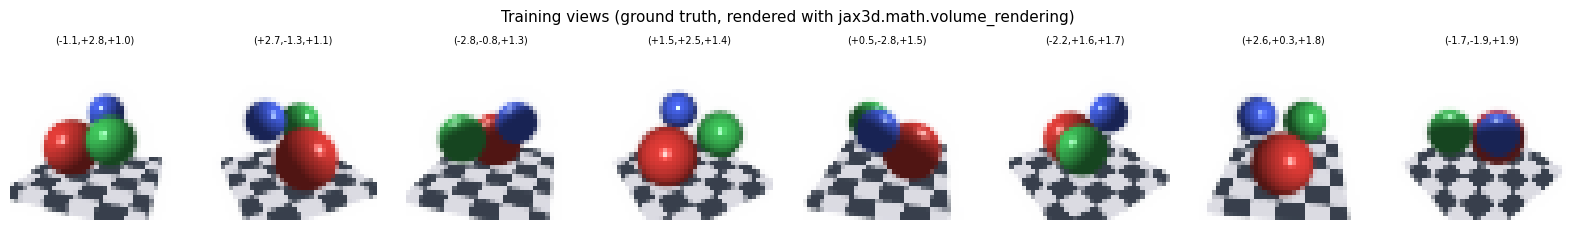

  ray pool: 22,400 rays

Model: 0.06M parameters (coarse + fine networks)
Training 400 steps x 1024 rays (32 coarse + 64 fine samples/ray) ...
  step     1/400 | loss 0.21301 | train PSNR  9.88 dB |   21.3s
  step    40/400 | loss 0.16033 | train PSNR 11.20 dB |   61.1s
  step    80/400 | loss 0.11793 | train PSNR 12.32 dB |  103.3s
  step   120/400 | loss 0.09572 | train PSNR 13.19 dB |  145.9s
  step   160/400 | loss 0.09064 | train PSNR 13.37 dB |  187.3s
  step   200/400 | loss 0.09194 | train PSNR 13.31 dB |  237.9s
  step   240/400 | loss 0.08761 | train PSNR 13.51 dB |  289.6s


In [ ]:
@jax.jit
def render_chunk(params, o, d, rng):
    _, out_f, aux = render_rays(params, o, d, rng, deterministic=True)
    return out_f.ray_values["rgb"], out_f.ray_depth, out_f.ray_alpha, aux

def render_image(params, origins, dirs, rng):
    """Chunked full-image render with padding, so only one shape gets compiled."""
    o = jnp.asarray(origins.reshape(-1, 3)); d = jnp.asarray(dirs.reshape(-1, 3))
    R = o.shape[0]; rgb, dep, alp = [], [], []
    for i in range(0, R, cfg.chunk):
        oc, dc = o[i:i + cfg.chunk], d[i:i + cfg.chunk]
        pad = cfg.chunk - oc.shape[0]
        if pad:
            oc = jnp.concatenate([oc, jnp.tile(oc[-1:], (pad, 1))], 0)
            dc = jnp.concatenate([dc, jnp.tile(dc[-1:], (pad, 1))], 0)
        c, dp, a, _ = render_chunk(params, oc, dc, rng)
        n = cfg.chunk - pad
        rgb.append(c[:n]); dep.append(dp[:n]); alp.append(a[:n])
    s = (cfg.H, cfg.W)
    return (np.asarray(jnp.concatenate(rgb)).reshape(*s, 3),
            np.asarray(jnp.concatenate(dep)).reshape(*s),
            np.asarray(jnp.concatenate(alp)).reshape(*s))

h = np.array(history)
plt.figure(figsize=(6, 3))
plt.plot(h[:, 0], h[:, 1], lw=1.6)
plt.xlabel("step"); plt.ylabel("train PSNR (dB)")
plt.title("Fine-network training PSNR"); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

print("\nRendering held-out test views ...")
key, k_eval = jax.random.split(key)
psnrs = []
fig, axes = plt.subplots(cfg.n_test_views, 4,
                         figsize=(11, 2.7 * cfg.n_test_views), squeeze=False)
for v in range(cfg.n_test_views):
    pred, depth, alpha = render_image(state.params, te_o[v], te_d[v], k_eval)
    p = float(mse_to_psnr(np.mean((pred - te_c[v]) ** 2))); psnrs.append(p)
    depth_vis = depth + (1.0 - alpha) * cfg.far
    for a, (im, ttl, kw) in zip(axes[v], [
            (np.clip(te_c[v], 0, 1), "ground truth", {}),
            (np.clip(pred, 0, 1), f"NeRF  ({p:.2f} dB)", {}),
            (depth_vis, "depth (ray_depth)", dict(cmap="turbo",
                                                  vmin=cfg.near, vmax=cfg.far)),
            (alpha, "opacity (ray_alpha)", dict(cmap="gray", vmin=0, vmax=1))]):
        a.imshow(im, **kw); a.set_title(ttl, fontsize=9); a.axis("off")
plt.suptitle(f"Novel-view synthesis   |   mean PSNR = {np.mean(psnrs):.2f} dB",
             fontsize=12)
plt.tight_layout(); plt.show()
print(f"  mean held-out PSNR: {np.mean(psnrs):.2f} dB")

cy, cx = cfg.H // 2, cfg.W // 2
o1 = jnp.asarray(te_o[0][cy, cx])[None]; d1 = jnp.asarray(te_d[0][cy, cx])[None]
o1 = jnp.tile(o1, (cfg.chunk, 1)); d1 = jnp.tile(d1, (cfg.chunk, 1))
_, _, _, aux = render_chunk(state.params, o1, d1, k_eval)
dc = np.asarray(aux["depths_c"][0]); wc = np.asarray(aux["weights_c"][0])
tf = np.asarray(aux["t_fine"][0])
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(dc, wc, width=(cfg.far - cfg.near) / cfg.n_coarse * .9,
       alpha=.55, label="coarse weights (the PDF)")
ax.plot(tf, np.full_like(tf, wc.max() * .06), "|", ms=16, color="crimson",
        label="fine samples (sample_piecewise_constant_pdf)")
ax.set_xlabel("depth along ray"); ax.set_ylabel("weight")
ax.set_title("Importance resampling concentrates samples on the surface")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

print("\nRendering 360-degree orbit ...")
n_frames = 24 if jax.devices()[0].platform != "cpu" else 8
frames = []
for t in range(n_frames):
    az = 2 * np.pi * t / n_frames; el = np.deg2rad(32.0)
    eye = cfg.cam_radius * np.array([np.cos(el) * np.cos(az),
                                     np.cos(el) * np.sin(az), np.sin(el)])
    o, d = rays_from_pose(look_at(eye), cfg.H, cfg.W, FOCAL)
    rgb, _, _ = render_image(state.params, o, d, k_eval)
    frames.append((np.clip(rgb, 0, 1) * 255).astype(np.uint8))
gif_path = os.path.join(os.getcwd(), "nerf_orbit.gif")
pil = [Image.fromarray(f).resize((cfg.W * 3, cfg.H * 3), Image.NEAREST) for f in frames]
pil[0].save(gif_path, save_all=True, append_images=pil[1:], duration=90, loop=0)
try:
    from IPython.display import Image as IPImage, display
    display(IPImage(filename=gif_path))
except Exception:
    pass
print("  saved", gif_path)

print("\nExtracting isosurface from the learned density field ...")
try:
    from skimage import measure
    g = np.linspace(-1.0, 1.0, cfg.grid_res, dtype=np.float32)
    X, Y, Z = np.meshgrid(g, g, g, indexing="ij")
    pts = np.stack([X, Y, Z], -1).reshape(-1, 3)

    @jax.jit
    def density_at(p):
        s, _ = model.apply(state.params["fine"], p, jnp.zeros_like(p))
        return s

    vol = np.concatenate([np.asarray(density_at(jnp.asarray(pts[i:i + 65536])))
                          for i in range(0, pts.shape[0], 65536)])
    vol = vol.reshape(cfg.grid_res, cfg.grid_res, cfg.grid_res)

    step = (cfg.far - cfg.near) / (cfg.n_coarse + cfg.n_fine)
    level = float(-np.log(0.5) / step)
    if not (vol.min() < level < vol.max()):
        level = float(np.percentile(vol, 99.0))
    verts, faces, _, _ = measure.marching_cubes(vol, level=level)
    verts = -1.0 + verts * (2.0 / (cfg.grid_res - 1))

    fig = plt.figure(figsize=(6, 6)); ax = fig.add_subplot(111, projection="3d")
    ax.plot_trisurf(verts[:, 0], verts[:, 1], verts[:, 2], triangles=faces,
                    cmap="viridis", lw=0.0, antialiased=False, alpha=.95)
    ax.set_box_aspect((1, 1, 1))
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
    ax.view_init(elev=24, azim=-58)
    ax.set_title(f"Marching cubes on learned density  (sigma = {level:.1f}, "
                 f"{len(faces):,} faces)", fontsize=10)
    plt.tight_layout(); plt.show()
except Exception as e:
    print("  isosurface step skipped:", e)

print("\n" + "=" * 70)
print(f"FINAL held-out PSNR: {np.mean(psnrs):.2f} dB   ({n_params/1e6:.2f}M params, "
      f"{cfg.steps} steps)")
print("jax3d functions exercised: sample_along_rays, volume_rendering, "
      "sample_piecewise_constant_pdf")
print("=" * 70)